## Shallow Neural Network
Build a shallow neural network to classify MNIST digits

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch 
import torch.nn as nn # Neural network layers and model building blocks
import torch.optim as optim # Optimization algorithms (ex: SGD, Adam)
from torchvision import datasets, transforms # MNIST dataset and preprocessing transforms
from torch.utils.data import DataLoader # Utilities for batching and shuffling data
import matplotlib.pyplot as plt

In [3]:
# Load MNIST and create train/test split

# Convert images to tensors and normalize with mean and std of MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
]) 

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Number of samples model processes at once during training/testing 
# Model sees 64 images at a time, computes loss and gradients, then updates weights. 
batch_size = 64 

# Create data loaders to handle batching and shuffling of data during training/testing
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 60000
Test size: 10000


In [4]:
# dataset.data inputs images, dataset.targets labels for each image
print("x_train shape:", train_dataset.data.shape, "y_train shape:", train_dataset.targets.shape)
print("x_test shape:", test_dataset.data.shape, "y_test shape:", test_dataset.targets.shape)

x_train shape: torch.Size([60000, 28, 28]) y_train shape: torch.Size([60000])
x_test shape: torch.Size([10000, 28, 28]) y_test shape: torch.Size([10000])


In [5]:
# Target labels for first 12 images in training set
train_dataset.targets[0:12]

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5])

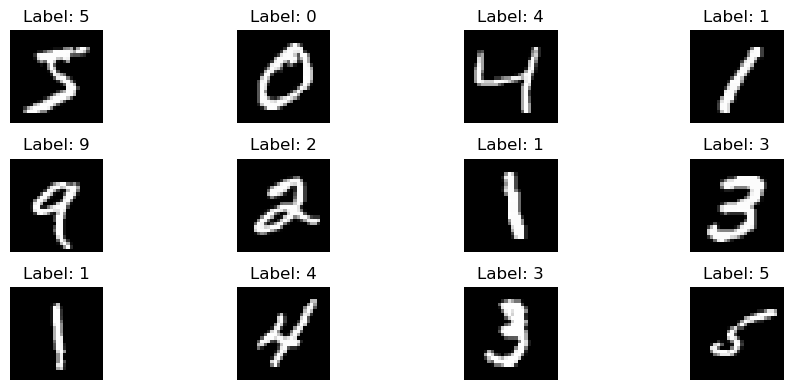

In [6]:
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(train_dataset.data[i], cmap="gray")
    plt.title(f"Label: {train_dataset.targets[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
model = nn.Sequential(
    nn.Flatten(),              # Convert 28x28 image tensors into 784-length 1D vectors, [Batch, 1, 28, 28] -> [Batch, 784]
    nn.Linear(784, 64),        # Hidden layer with 64 neurons
    nn.Sigmoid(),              # Sigmoid activation for the hidden layer
    nn.Linear(64, 10),         # Output layer for 10 MNIST classes
    nn.Softmax(dim=1)          # Convert logits to class probabilities
)

In [ ]:
from torchinfo import summary

print(model)
print("\n" + "="*60)
summary(model, input_size=(1, 1, 28, 28))  # Batch size 1, 1 channel, 28x28 image

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=64, bias=True)
  (2): Sigmoid()
  (3): Linear(in_features=64, out_features=10, bias=True)
  (4): Softmax(dim=1)
)
Total model parameters: 50890


In [12]:
# Model training loop with GPU support if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)
model = model.to(device)


criterion = nn.MSELoss() # MSE loss compares predicted probabilities to one-hot encoded true labels, penalizing incorrect predictions more heavily
optimizer = optim.SGD(model.parameters(), lr=0.2) # Gradient Descent optimizer updates model weights based on computed gradients and learning rate

# epoch = one full pass through the entire training dataset (all batches)
# Steps/iterations per epoch = (dataset_size / batch_size)
# Each step: forward pass on one batch -> compute loss -> backward pass -> optimizer.step()

epochs = 30
for epoch in range(epochs):
    model.train() # Set model to training mode (enables dropout, batch norm, etc. if present)
    running_loss = 0.0 # Cumulative loss for the current epoch, used to compute average loss at the end of the epoch
    correct = 0 # Number of correct predictions for the current epoch, used to compute training accuracy
    total = 0 # Total number of samples processed in the current epoch, used to compute training accuracy

    # Iterate over mini-batches from the training loader
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        targets = nn.functional.one_hot(labels, num_classes=10).float() # Convert labels to one-hot encoding 

        optimizer.zero_grad() # Clear previous gradients before backpropagation
        outputs = model(images) # Forward pass: compute predicted probabilities for the current batch
        loss = criterion(outputs, targets) # Compute loss between predicted probabilities and one-hot encoded true labels
        loss.backward() # Backward pass: compute gradients of the loss with respect to model parameters
        optimizer.step() # Update model parameters based on computed gradients and learning rate

        # Track loss and accuracy for the current epoch
        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1) # Get predicted class 
        correct += (predicted == labels).sum().item() # Count correct predictions in the current batch
        total += labels.size(0)

    train_loss = running_loss / total # Epoch average loss per sample
    train_acc = correct / total # Epoch training accuracy 

    # Evaluate on the test split without computing gradients
    model.eval() # Set model to evaluation mode (disables dropout, batch norm updates, etc.)
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images) # Forward pass on test data to compute predicted probabilities
            predicted = outputs.argmax(dim=1) # Get predicted class
            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    test_acc = test_correct / test_total
    print(f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.4f} - train acc: {train_acc:.4f} - test acc: {test_acc:.4f}")

Using device: mps
Epoch 1/30 - loss: 0.0735 - train acc: 0.4769 - test acc: 0.6448
Epoch 2/30 - loss: 0.0418 - train acc: 0.7594 - test acc: 0.8502
Epoch 3/30 - loss: 0.0267 - train acc: 0.8688 - test acc: 0.8915
Epoch 4/30 - loss: 0.0205 - train acc: 0.8893 - test acc: 0.9005
Epoch 5/30 - loss: 0.0177 - train acc: 0.8988 - test acc: 0.9072
Epoch 6/30 - loss: 0.0161 - train acc: 0.9051 - test acc: 0.9136
Epoch 7/30 - loss: 0.0150 - train acc: 0.9097 - test acc: 0.9159
Epoch 8/30 - loss: 0.0141 - train acc: 0.9140 - test acc: 0.9200
Epoch 9/30 - loss: 0.0134 - train acc: 0.9179 - test acc: 0.9233
Epoch 10/30 - loss: 0.0129 - train acc: 0.9208 - test acc: 0.9252


KeyboardInterrupt: 